In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

print('Импорты работают')

Импорты работают


In [29]:
iris=load_iris()
print(type(iris))
print(iris.keys())

<class 'sklearn.utils._bunch.Bunch'>
dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])


In [30]:
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species']=iris.target
df['species_name'] = df['species'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species,species_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [31]:
df['species_name'].value_counts()

species_name
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

In [32]:
df.shape
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [33]:
X = df[iris.feature_names]
y = df['species']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print('Train:',X_train.shape, y_train.shape)
print('Test:', X_test.shape, y_test.shape)

Train: (120, 4) (120,)
Test: (30, 4) (30,)


In [34]:
model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)

print('END')

END


In [35]:
y_pred=model.predict(X_test)
print('Предсказания:', y_pred)
print('Правда:      ', y_test.values)

Предсказания: [1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]
Правда:       [1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]


In [36]:
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.2%}')

Accuracy: 100.00%


[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


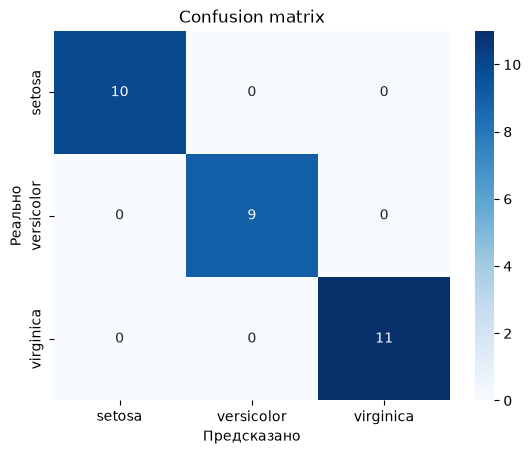

In [37]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

sns.heatmap(cm, annot=True, cmap='Blues',
            xticklabels=iris.target_names,
            yticklabels=iris.target_names)
plt.xlabel('Предсказано')
plt.ylabel('Реально')
plt.title('Confusion matrix')
plt.show()

In [45]:
from sklearn.tree import DecisionTreeClassifier

model2=DecisionTreeClassifier(max_depth=3, random_state=42)
model2.fit(X_train, y_train)
y_pred2=model2.predict(X_test)

print(f"LogisticRegresiion: {accuracy_score(y_test, y_pred):.2%}")
print(f"DecisionTree:       {accuracy_score(y_test, y_pred2):.2%}")

LogisticRegresiion: 100.00%
DecisionTree:       100.00%
